In [16]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import forestplot as fplt
from scipy import stats

from standes.intensitymeasures import avgsa_03
from standes.groundmotion import load_ground_motion_from_json
from standes.fitting import lognorm_moment_fit

from phd_project.scripts.femap695_records import femap695_record_tags, record_tag_to_column
import phd_project.scripts.metaregression_analysis as mra
from phd_project.config import config

cfg = config.load_config()

In [17]:
ROOT = cfg["analysis_data"]["wp1_fixed_record_sets"]
# ROOT = Path(r"C:\Users\clemettn\Desktop\test_folder")
FEMA_RECS = cfg["raw_data"]["femap695_records"]

BOOTSTRAP_PTH = cfg["proc_data"]["bootstrapping"]
SAMPLES_CSV = BOOTSTRAP_PTH / "femap695_bootstrapped_indices.csv"
K_SAMPLES = 10
IM_TAG = "AvgSA_03"

N_STOREYS = [3]
storey_codes = [f"{n}s" for n in N_STOREYS]
groups = [f for f in os.listdir(ROOT) if (ROOT / f).is_dir() and f.startswith("group") and f.split("_")[1] in storey_codes]

# get record tags of FEMA records:
rec_tags = femap695_record_tags(FEMA_RECS)
rec_tag_map = record_tag_to_column(rec_tags)

# get the ida record logs for each group
ida_logs = {}
for group in groups:
    ns = group.split("_")[1]
    num = int(group.split("_")[2])
    ida_log_path = ROOT / group / f"{ns}/mdof/ida_femap695/record_logs.json"

    with open(ida_log_path, "r") as file:
        ida_logs[group] = json.load(file)

# get the msa logs for each group
msa_logs = {}
for group in groups:
    ns = group.split("_")[1]
    num = int(group.split("_")[2])
    msa_log_path = ROOT / group / f"{ns}/mdof/msa_AvgSA_03_femap695/msa_log.json"

    with open(msa_log_path, "r") as file:
        msa_logs[group] = json.load(file)

In [19]:
## get the AvgSA[0,3] imls for each of the FEMA-Records
rec_fps = [FEMA_RECS / f"{tag}.json" for tag in rec_tags]
gm_records = {idx: load_ground_motion_from_json(rec_fp)
              for idx, rec_fp in enumerate(rec_fps)}
gm_AvgSAs = {idx: avgsa_03().calculate_iml(gm, gravity_factor=1) for idx, gm in gm_records.items()}
gm_AvgSAs = pd.Series(gm_AvgSAs, name="AvgSA_ref")

In [20]:
def ida_collapse_capacities(ida_log):
    """Per-record collapse bracket, in the same IM as gm_AvgSAs.

    lb is the highest analysed intensity that produced a result (collapsed is False) -
    ub is the lowest intensity that collapsed.

    avg_iml is the *geometric* mean of the two. The error the bracket leaves behind is
    uniform in log space (see the Summary), so the log midpoint is the estimate with no
    expected error; the arithmetic midpoint sits ln(AM/GM) ~ 0.0007 above it.
    """
    lb, ub = {}, {}
    for rec_idx, rec_log in ida_log.items():
        if len(rec_log["run_logs"]) > 1:
            raise ValueError(f"record {rec_idx}: multiple starts")
        runs = [v for k, v in rec_log["run_logs"]["start_1"].items() if k.isnumeric()]
        lb[int(rec_idx)] = max(v["scale_factor"] for v in runs if not v["collapsed"])
        ub[int(rec_idx)] = min(v["scale_factor"] for v in runs if v["collapsed"])

    df_sf = pd.DataFrame({"nc_sf": lb, "c_sf": ub}).sort_index()
    if not df_sf.index.equals(pd.Index(range(len(rec_tags)))):
        raise ValueError(f"records {sorted(set(range(len(rec_tags))) - set(df_sf.index))} missing")

    ## Get the AvgSA[0,3] values corresponding to each scale factor
    df_AvgSA = df_sf.mul(gm_AvgSAs, axis=0) 
    df_AvgSA = df_AvgSA.rename(columns={"c_sf":"ub_iml", "nc_sf":"lb_iml"}) 
    df_AvgSA["avg_iml"] = np.sqrt(df_AvgSA["ub_iml"] * df_AvgSA["lb_iml"])

    return df_AvgSA

collapse_imls_per_group = {}
ub_collapse_imls = {}
lb_collapse_imls = {}
avg_collapse_imls = {}

for group, ida_log in ida_logs.items():
    df_collapse_imls = ida_collapse_capacities(ida_log)
    collapse_imls_per_group[group] = df_collapse_imls
    ub_collapse_imls[group] = df_collapse_imls["ub_iml"]
    lb_collapse_imls[group] = df_collapse_imls["lb_iml"]
    avg_collapse_imls[group] = df_collapse_imls["avg_iml"]

lb_collapse_imls = pd.DataFrame.from_dict(lb_collapse_imls, orient="index")
lb_collapse_imls.columns = [str(c) for c in lb_collapse_imls.columns]
ub_collapse_imls = pd.DataFrame.from_dict(ub_collapse_imls, orient="index")
ub_collapse_imls.columns = [str(c) for c in ub_collapse_imls.columns]
avg_collapse_imls = pd.DataFrame.from_dict(avg_collapse_imls, orient="index")
avg_collapse_imls.columns = [str(c) for c in avg_collapse_imls.columns]

In [21]:
# get the theta and beta estimates for each collapse definition
lb_fit = lb_collapse_imls.apply(lognorm_moment_fit, axis=1, result_type="expand")
lb_fit.columns = ["theta", "beta"] 
ub_fit = ub_collapse_imls.apply(lognorm_moment_fit, axis=1, result_type="expand") 
ub_fit.columns = ["theta", "beta"] 
avg_fit = avg_collapse_imls.apply(lognorm_moment_fit, axis=1, result_type="expand") 
avg_fit.columns = ["theta", "beta"] 

In [22]:
# load the msa models:
mgr_ests = mra.load_estimates(BOOTSTRAP_PTH, IM_TAG, arms=["msa_femap695"], scope="by_group")["msa_femap695"]
msa_gr = mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "msa_femap695", ("theta", "beta"), 3, IM_TAG, "by_group",
        k_samples=K_SAMPLES)

theta_mgr = msa_gr["theta"].T
theta_mgr = theta_mgr.loc[lb_fit.index, :]

theta_est_mgr = mgr_ests["theta"].T
theta_est_mgr = theta_est_mgr.set_axis([i[0] for i in mgr_ests["theta"].index])
theta_est_mgr = theta_est_mgr[lb_fit.index] 

In [23]:
## Now redo the fragility fitting for each of the different collapse definitions:

# Reload the drawn sample, so 1.2 can be re-run without redrawing it. The checks guard
# against the sample on disk having been drawn from a different record set.
samples = np.loadtxt(SAMPLES_CSV, delimiter=",", dtype=str)
assert samples.shape == (K_SAMPLES, len(rec_tags))
assert set(np.unique(samples)) <= set(rec_tags)
samples.shape

theta_lb, beta_lb = mra.bootstrap_ida_group_fragilities(
    lb_collapse_imls, samples, rec_tags)

theta_ub, beta_ub = mra.bootstrap_ida_group_fragilities(
    ub_collapse_imls, samples, rec_tags)

theta_avg, beta_avg = mra.bootstrap_ida_group_fragilities(
    avg_collapse_imls, samples, rec_tags)

## 2.0 RE Models for the different IDA collapse definitions

### 2.1 Lower Bound

Heterogeneity tests for the effect size (mss/mfx) in log units:
  Q    : 19.8817
  Q_df : -4.1183
  T_sq : 0.0000
  T    : 0.0000
  I_sq : 0.0000

Mean Effect: 1.0434    <-- the mean effect size (mfx/ifx) in real units
Variance of M: 9.030e-06    <-- the variance of the mean effect size (mfx/ifx) in real units
T²: 0.000e+00    <-- the between-study variance (mfx/ifx) in real units

Prediction Interval: 1.0336 - 1.0533    <-- where new data is expected to fall 95% of the time
Summary Effect CI: 1.0358 - 1.0537    <-- where the true summary effect is expected to fall with 95% confidence
Mean Effect: 1.0434    <-- the mean effect size (mss/mfx) in real units
SE_boot 0.004565162276537452 SE_model 0.0030050664660142465


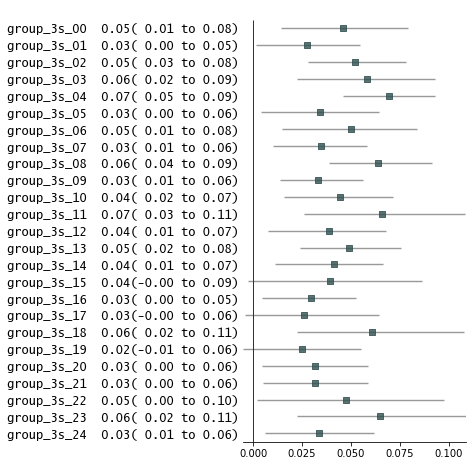

In [24]:
# 1. Calculate the effect size for each study
# get the difference in log units (same as the ratio in real units)
y0 = np.log(theta_mgr) - np.log(theta_lb.T)    # mfx - ifx     shape(n_rows, k_samples)
y0_est = np.log(theta_est_mgr) - np.log(lb_fit["theta"])      # mfx - ifx direct from fragilities (n_rows, 1)
# calculate the total variance directly from the bootstrap samples which will 
# automatically contain any covariance incase they aren't fully independent. 
v0_boot = y0.var(axis=1)    # variance along a row -> reduce the columns 

# get the upper and lower confidence interval for the forest plot.
# just use percentile samples as they are transformation respecting
lb = y0.quantile(q=0.025, axis=1, numeric_only=True)
ub = y0.quantile(q=0.975, axis=1, numeric_only=True)

# set the labels for each row
labels = [g for g in y0_est.index]
# 2. create a forest plot
df = pd.DataFrame({"effect": y0_est.to_numpy(), 
                   "lb": lb.to_numpy(), 
                   "ub": ub.to_numpy(), 
                   "labels": labels
                   })
fplt.forestplot(df, estimate="effect", ll="lb", hl="ub", varlabel="labels")

# heterogeneity analysis
het_tests = mra.compute_heterogeneity_stats(v0_boot, y0_est)
print("Heterogeneity tests for the effect size (mss/mfx) in log units:")
for test, value in het_tests.items():
    print(f"  {test:<5}: {value:.4f}")
# Fit the model to the estimates to get the effect size.
M_star_est, V_star_est, SE_star_est, T_sq, Wis_re = mra.compute_re_summary_effect(v0_boot, y0_est, len(y0_est))
# Fit the model for each replicate and store the summary effect for each replicate. 
# This will give us a distribution of the summary effect which we can use to get the confidence interval.
replicate_fits = []
for col in y0.columns:
    y0_col = y0[col]
    # just drop the weights from the summary effect as we don't need them for anything
    replicate_fits.append(mra.compute_re_summary_effect(v0_boot, y0_col, len(y0_col))[:-1])

replicate_fits = pd.DataFrame(replicate_fits, columns=["M_star", "V_star", "SE_star", "T_sq"])

print(f"\nMean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mfx/ifx) in real units")
print(f"Variance of M: {V_star_est:.3e}    <-- the variance of the mean effect size (mfx/ifx) in real units")
print(f"T²: {T_sq:.3e}    <-- the between-study variance (mfx/ifx) in real units")
# calculate the variance of the summary effect
V_m0_boot = replicate_fits["M_star"].var(axis=0, numeric_only=True)

# calculate the CI of the summary effect using the bootstrap replicates (%-ile intervals)
lb_m0_boot = replicate_fits["M_star"].quantile(q=0.025)
ub_m0_boot = replicate_fits["M_star"].quantile(q=0.975)

# calculate the prediction interval of the summary effect using the bootstrap variance and the t-distribution.
# This accounts for the variance in the summary effect and the variance in the individual studies.
LL_pred = M_star_est - stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_boot)
UL_pred = M_star_est + stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_boot)

print(f"\nPrediction Interval: {np.exp(LL_pred):.4f} - {np.exp(UL_pred):.4f}    <-- where new data is expected to fall 95% of the time")
print(f"Summary Effect CI: {np.exp(lb_m0_boot):.4f} - {np.exp(ub_m0_boot):.4f}    <-- where the true summary effect is expected to fall with 95% confidence")
print(f"Mean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mss/mfx) in real units")
# compare the SE on the summary effect from the model fit and the bootstrap replicates.
# If the model is truely independent then they should be similar. If the model is not independent 
# then the bootstrap replicates will have a larger variance than the model fit. We should use the 
# bootstrap version.
print("SE_boot", np.sqrt(V_m0_boot), "SE_model", SE_star_est)

### 2.2 Upper Bound

Heterogeneity tests for the effect size (mss/mfx) in log units:
  Q    : 16.9332
  Q_df : -7.0668
  T_sq : 0.0000
  T    : 0.0000
  I_sq : 0.0000

Mean Effect: 0.9693    <-- the mean effect size (mfx/ifx) in real units
Variance of M: 9.139e-06    <-- the variance of the mean effect size (mfx/ifx) in real units
T²: 0.000e+00    <-- the between-study variance (mfx/ifx) in real units

Prediction Interval: 0.9599 - 0.9789    <-- where new data is expected to fall 95% of the time
Summary Effect CI: 0.9623 - 0.9801    <-- where the true summary effect is expected to fall with 95% confidence
Mean Effect: 0.9693    <-- the mean effect size (mss/mfx) in real units
SE_boot 0.004732402178967512 SE_model 0.003023148280742268


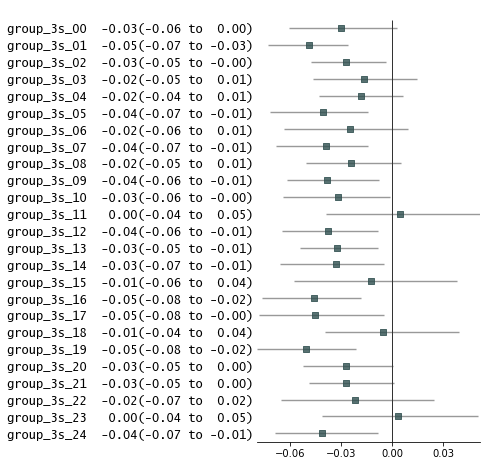

In [25]:
# 1. Calculate the effect size for each study
# get the difference in log units (same as the ratio in real units)
y0 = np.log(theta_mgr) - np.log(theta_ub.T)    # mfx - ifx     shape(n_rows, k_samples)
y0_est = np.log(theta_est_mgr) - np.log(ub_fit["theta"])      # mfx - ifx direct from fragilities (n_rows, 1)
# calculate the total variance directly from the bootstrap samples which will 
# automatically contain any covariance incase they aren't fully independent. 
v0_boot = y0.var(axis=1)    # variance along a row -> reduce the columns 

# get the upper and lower confidence interval for the forest plot.
# just use percentile samples as they are transformation respecting
lb = y0.quantile(q=0.025, axis=1, numeric_only=True)
ub = y0.quantile(q=0.975, axis=1, numeric_only=True)

# set the labels for each row
labels = [g for g in y0_est.index]
# 2. create a forest plot
df = pd.DataFrame({"effect": y0_est.to_numpy(), 
                   "lb": lb.to_numpy(), 
                   "ub": ub.to_numpy(), 
                   "labels": labels
                   })
fplt.forestplot(df, estimate="effect", ll="lb", hl="ub", varlabel="labels")

# heterogeneity analysis
het_tests = mra.compute_heterogeneity_stats(v0_boot, y0_est)
print("Heterogeneity tests for the effect size (mss/mfx) in log units:")
for test, value in het_tests.items():
    print(f"  {test:<5}: {value:.4f}")
# Fit the model to the estimates to get the effect size.
M_star_est, V_star_est, SE_star_est, T_sq, Wis_re = mra.compute_re_summary_effect(v0_boot, y0_est, len(y0_est))
# Fit the model for each replicate and store the summary effect for each replicate. 
# This will give us a distribution of the summary effect which we can use to get the confidence interval.
replicate_fits = []
for col in y0.columns:
    y0_col = y0[col]
    # just drop the weights from the summary effect as we don't need them for anything
    replicate_fits.append(mra.compute_re_summary_effect(v0_boot, y0_col, len(y0_col))[:-1])

replicate_fits = pd.DataFrame(replicate_fits, columns=["M_star", "V_star", "SE_star", "T_sq"])

print(f"\nMean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mfx/ifx) in real units")
print(f"Variance of M: {V_star_est:.3e}    <-- the variance of the mean effect size (mfx/ifx) in real units")
print(f"T²: {T_sq:.3e}    <-- the between-study variance (mfx/ifx) in real units")
# calculate the variance of the summary effect
V_m0_boot = replicate_fits["M_star"].var(axis=0, numeric_only=True)

# calculate the CI of the summary effect using the bootstrap replicates (%-ile intervals)
lb_m0_boot = replicate_fits["M_star"].quantile(q=0.025)
ub_m0_boot = replicate_fits["M_star"].quantile(q=0.975)

# calculate the prediction interval of the summary effect using the bootstrap variance and the t-distribution.
# This accounts for the variance in the summary effect and the variance in the individual studies.
LL_pred = M_star_est - stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_boot)
UL_pred = M_star_est + stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_boot)

print(f"\nPrediction Interval: {np.exp(LL_pred):.4f} - {np.exp(UL_pred):.4f}    <-- where new data is expected to fall 95% of the time")
print(f"Summary Effect CI: {np.exp(lb_m0_boot):.4f} - {np.exp(ub_m0_boot):.4f}    <-- where the true summary effect is expected to fall with 95% confidence")
print(f"Mean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mss/mfx) in real units")
# compare the SE on the summary effect from the model fit and the bootstrap replicates.
# If the model is truely independent then they should be similar. If the model is not independent 
# then the bootstrap replicates will have a larger variance than the model fit. We should use the 
# bootstrap version.
print("SE_boot", np.sqrt(V_m0_boot), "SE_model", SE_star_est)

### 2.3 Average

Heterogeneity tests for the effect size (mss/mfx) in log units:
  Q    : 17.0784
  Q_df : -6.9216
  T_sq : 0.0000
  T    : 0.0000
  I_sq : 0.0000

Mean Effect: 1.0048    <-- the mean effect size (mfx/ifx) in real units
Variance of M: 8.786e-06    <-- the variance of the mean effect size (mfx/ifx) in real units
T²: 0.000e+00    <-- the between-study variance (mfx/ifx) in real units

Prediction Interval: 0.9954 - 1.0143    <-- where new data is expected to fall 95% of the time
Summary Effect CI: 0.9977 - 1.0152    <-- where the true summary effect is expected to fall with 95% confidence
Mean Effect: 1.0048    <-- the mean effect size (mss/mfx) in real units
SE_boot 0.004542225594415289 SE_model 0.0029641972507965493


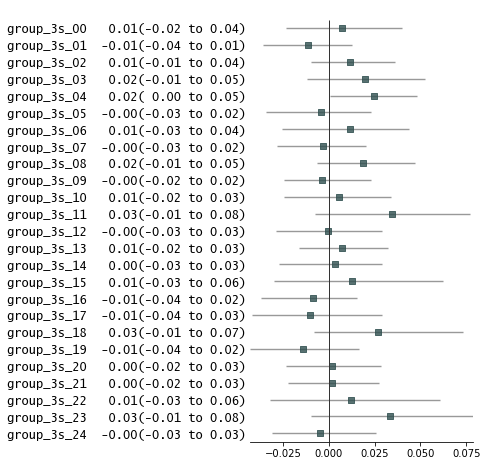

In [26]:
# 1. Calculate the effect size for each study
# get the difference in log units (same as the ratio in real units)
y0 = np.log(theta_mgr) - np.log(theta_avg.T)    # mfx - ifx     shape(n_rows, k_samples)
y0_est = np.log(theta_est_mgr) - np.log(avg_fit["theta"])      # mfx - ifx direct from fragilities (n_rows, 1)
# calculate the total variance directly from the bootstrap samples which will 
# automatically contain any covariance incase they aren't fully independent. 
v0_boot = y0.var(axis=1)    # variance along a row -> reduce the columns 

# get the upper and lower confidence interval for the forest plot.
# just use percentile samples as they are transformation respecting
lb = y0.quantile(q=0.025, axis=1, numeric_only=True)
ub = y0.quantile(q=0.975, axis=1, numeric_only=True)

# set the labels for each row
labels = [g for g in y0_est.index]
# 2. create a forest plot
df = pd.DataFrame({"effect": y0_est.to_numpy(), 
                   "lb": lb.to_numpy(), 
                   "ub": ub.to_numpy(), 
                   "labels": labels
                   })
fplt.forestplot(df, estimate="effect", ll="lb", hl="ub", varlabel="labels")

# heterogeneity analysis
het_tests = mra.compute_heterogeneity_stats(v0_boot, y0_est)
print("Heterogeneity tests for the effect size (mss/mfx) in log units:")
for test, value in het_tests.items():
    print(f"  {test:<5}: {value:.4f}")
# Fit the model to the estimates to get the effect size.
M_star_est, V_star_est, SE_star_est, T_sq, Wis_re = mra.compute_re_summary_effect(v0_boot, y0_est, len(y0_est))
# Fit the model for each replicate and store the summary effect for each replicate. 
# This will give us a distribution of the summary effect which we can use to get the confidence interval.
replicate_fits = []
for col in y0.columns:
    y0_col = y0[col]
    # just drop the weights from the summary effect as we don't need them for anything
    replicate_fits.append(mra.compute_re_summary_effect(v0_boot, y0_col, len(y0_col))[:-1])

replicate_fits = pd.DataFrame(replicate_fits, columns=["M_star", "V_star", "SE_star", "T_sq"])

print(f"\nMean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mfx/ifx) in real units")
print(f"Variance of M: {V_star_est:.3e}    <-- the variance of the mean effect size (mfx/ifx) in real units")
print(f"T²: {T_sq:.3e}    <-- the between-study variance (mfx/ifx) in real units")
# calculate the variance of the summary effect
V_m0_boot = replicate_fits["M_star"].var(axis=0, numeric_only=True)

# calculate the CI of the summary effect using the bootstrap replicates (%-ile intervals)
lb_m0_boot = replicate_fits["M_star"].quantile(q=0.025)
ub_m0_boot = replicate_fits["M_star"].quantile(q=0.975)

# calculate the prediction interval of the summary effect using the bootstrap variance and the t-distribution.
# This accounts for the variance in the summary effect and the variance in the individual studies.
LL_pred = M_star_est - stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_boot)
UL_pred = M_star_est + stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_boot)

print(f"\nPrediction Interval: {np.exp(LL_pred):.4f} - {np.exp(UL_pred):.4f}    <-- where new data is expected to fall 95% of the time")
print(f"Summary Effect CI: {np.exp(lb_m0_boot):.4f} - {np.exp(ub_m0_boot):.4f}    <-- where the true summary effect is expected to fall with 95% confidence")
print(f"Mean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mss/mfx) in real units")
# compare the SE on the summary effect from the model fit and the bootstrap replicates.
# If the model is truely independent then they should be similar. If the model is not independent 
# then the bootstrap replicates will have a larger variance than the model fit. We should use the 
# bootstrap version.
print("SE_boot", np.sqrt(V_m0_boot), "SE_model", SE_star_est)

## 3.0 Collapse Brackets

In [27]:
log_collapse_brackets = {}
mean_brackets = []
for group, collapse_imls in collapse_imls_per_group.items():
    log_bracket = np.log(collapse_imls.ub_iml/collapse_imls.lb_iml)
    log_collapse_brackets[group] = log_bracket
    mean_brackets.append(log_bracket.mean())

# the mean bracket over all groups
mean_brackets = np.array(mean_brackets)
mean_bracket = mean_brackets.mean()

print(f"Mean of the log of the ida collapse bracket: {mean_bracket:.4f}")
print(f"Mean ida collapse bracket in real units: {np.exp(mean_bracket):.4f}")

Mean of the log of the ida collapse bracket: 0.0724
Mean ida collapse bracket in real units: 1.0751


## Summary

From the forestplots and the mean effect size we can see that when we take the highest non collapsed iml in the IDA as our collapse capacity we are biasing the collapse capacity downwards compared to the MSA result (§2.1). If we take the lowest collapsed iml then the collapse capacity is biased upwards compared to the MSA result (§2.2). Finally, if the geometric average of the upper and lower bound iml is used then the results are not biased with respect to the MSA results.

The bias of ~4.3% can be explained as follows:

The error between the "true" collapse value, $T_i$, and the lower bound value, $L_i$, for record $i$ is $$\varepsilon_i = \ln{\frac{T_i}{L_i}} \in \left(0, \ln\frac{U_i}{L_i}\right)$$ where $U_i$ is the upper bound value on the collapse capacity for the record $i$. From the definition of the IDA algorithm that has been implemented we know that the ratio $r=\frac{U_i}{L_i}\leq1.1$, i.e. the maximum difference between the upper and lower collapse bound is 10%. If we assume that $T_i$ is uniformly distributed on $\left(L_i, U_i\right)$ then $\varepsilon_i$ is uniformly distributed on $\left(0, \ln\frac{U_i}{L_i}\right) = (0, \ln{1.1})$. Calculating the expectation of $X\sim\mathcal{U}(a,b)$ is $$\mathbb{E}[X] = \frac{(a + b)}{2}$$ so the expectation of $\varepsilon$ is $$\mathbb{E}[\varepsilon_i] = \frac{(0 + \ln{1.1})}{2} = 0.04766$$ taking the exponential converts this into real units and we get 1.0488 or a 4.9% underestimation by IDA. Following this logic is it clear that if we substitute $U_i$ for $L_i$ then we would expected the same error just in the other direction, and substituting the geometric average for $L_i$ we would get no expected error.

The reported mean error is a bit less than the 4.9% from the theory and this is because we have assumed a constant 10% range between the highest noncollapse iml and the lowest collapse iml. This is not the case everywhere because the IDA algorithm used makes the trace step the minimum of 1/3 the distance between the last noncollapse iml and the lowest collapse iml or 10% of the last noncollapse iml. This means that in some cases the band width is less than 10% which drags down the mean effect size slightly (4.3% vs 4.9%).

We can actually test what the mean bandwidth across all structures and records should be. This was done in `nb 074` §3.0 and it is 7.51%. The difference between the expected effect size $M^*_L$ and $M^*_U$ is should be this log average. $$\ln{M^*_L}-\ln{M^*_U} = \ln{1.0434} - \ln{0.9693} = 0.0737$$

Based on the uniform assumption we would expect the average of the log of the mean effects of the upper and lower collapse imls to be zero. $$0.5(\ln{M^*_L}+\ln{M^*_U}) = 0.5(\ln{1.0434} - \ln{0.9693}) = 0.00562$$ This is not zero, which indicates some level of bias. The bias is approximately $1.2\times SE$ ($SE = 0.0046$ from the bootstrap). The residual is therefore not significantly different from zero at 95% confidence, though not completely negligible either. Either way it is small.

The conclusions from this little investigation are:
1. The the HTF algorithm as implemented by Vamvatsikos and Cornell (taking the highest noncollapsing IML) results in an ~4.3% underestimation in the median collapse capacity compared to MSA results with the same record set. Vamvatsikos says that the average or the upper bound would also be ok choices.
2. If this difference is corrected for i.e. the geometric average of the upper and lower bound is used to predict the collapse capacity then there is no meaningful difference in the values of median fragility obtained from IDA and MSA. (based on the structures that we have assessed here)

What does this mean for the rest of my models?
1. We can redfine the collapse point of the IDA-FX and then use the redefined collapse capacities to better estimate the difference between MSA-SS and IDA-FX 